# HR Analytics AI System
## Notebook 4: Feature Engineering

Feature Engineering is the process of creating new meaningful features
from existing data to improve the performance of machine learning models.

In this notebook, we will create the following new features:

1. Engagement Score — measures how engaged an employee is with their work
2. Experience Level — categorizes employees based on their total working years
3. Income Level — categorizes employees based on their monthly income
4. Risk Score — estimates the likelihood of an employee leaving the company
5. Satisfaction Score — combines multiple satisfaction metrics into one indicator

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Initialize Spark Session and Load Data

We initialize the Spark Session and load the preprocessed dataset
from the Parquet file saved in Notebook 2.

In [2]:
spark = SparkSession.builder \
    .appName("HR Analytics - Feature Engineering") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet(
    r"C:\HR-Analytics-AI-System\data\hr_data_preprocessed.parquet"
)

print("Data Loaded Successfully.")
print(f"Total Rows: {df.count()}")
print(f"Total Columns: {len(df.columns)}")

Data Loaded Successfully.
Total Rows: 1470
Total Columns: 31


### 2. Engagement Score

The Engagement Score combines three key metrics that reflect
how engaged an employee is with their work:

- **JobInvolvement:** How involved the employee is in their job (1-4)
- **JobSatisfaction:** How satisfied the employee is with their job (1-4)
- **RelationshipSatisfaction:** How satisfied the employee is with workplace relationships (1-4)

The score is calculated as the average of these three metrics,
resulting in a value between 1 and 4, where 4 indicates the highest engagement.

In [3]:
df = df.withColumn(
    "EngagementScore",
    F.round(
        (F.col("JobInvolvement") + F.col("JobSatisfaction") + F.col("RelationshipSatisfaction")) / 3, 2
    )
)

print("Engagement Score created successfully.")
print("-" * 40)
df.select("JobInvolvement", "JobSatisfaction", "RelationshipSatisfaction", "EngagementScore") \
  .show(5)

print("Engagement Score Statistics:")
df.select("EngagementScore").describe().show()

Engagement Score created successfully.
----------------------------------------
+--------------+---------------+------------------------+---------------+
|JobInvolvement|JobSatisfaction|RelationshipSatisfaction|EngagementScore|
+--------------+---------------+------------------------+---------------+
|             3|              4|                       1|           2.67|
|             2|              2|                       4|           2.67|
|             2|              3|                       2|           2.33|
|             3|              3|                       3|            3.0|
|             3|              2|                       4|            3.0|
+--------------+---------------+------------------------+---------------+
only showing top 5 rows

Engagement Score Statistics:
+-------+-----------------+
|summary|  EngagementScore|
+-------+-----------------+
|  count|             1470|
|   mean|2.723544217687073|
| stddev|0.565829833092598|
|    min|              1.0|
|   

### Engagement Score Results

The Engagement Score was successfully created with the following statistics:

- **Average Score:** 2.72 out of 4, indicating a moderate level of engagement
- **Minimum Score:** 1.0, representing the least engaged employees
- **Maximum Score:** 4.0, representing the most engaged employees

This score will serve as an important feature in our attrition prediction model,
as lower engagement is typically associated with higher attrition risk.

### 3. Experience Level

We categorize employees into experience levels based on their total working years.
This helps the model understand the career stage of each employee,
which is an important factor in predicting attrition.

In [4]:
df = df.withColumn(
    "ExperienceLevel",
    F.when(F.col("TotalWorkingYears") <= 2, "Entry Level")
     .when((F.col("TotalWorkingYears") > 2) & (F.col("TotalWorkingYears") <= 7), "Junior")
     .when((F.col("TotalWorkingYears") > 7) & (F.col("TotalWorkingYears") <= 15), "Mid-Level")
     .when((F.col("TotalWorkingYears") > 15) & (F.col("TotalWorkingYears") <= 25), "Senior")
     .otherwise("Executive")
)

exp_dist = df.groupBy("ExperienceLevel").count().orderBy("count", ascending=False).toPandas()

print("Experience Level Distribution:")
print("-" * 40)
print(exp_dist.to_string(index=False))

Experience Level Distribution:
----------------------------------------
ExperienceLevel  count
      Mid-Level    592
         Junior    399
         Senior    258
    Entry Level    123
      Executive     98


### Experience Level Results

Employees were successfully categorized into five experience levels:

- **Mid-Level** is the largest group with 592 employees (7-15 years of experience)
- **Junior** follows with 399 employees (3-7 years of experience)
- **Senior** contains 258 employees (16-25 years of experience)
- **Entry Level** contains 123 employees (0-2 years of experience)
- **Executive** contains 98 employees (more than 25 years of experience)

This distribution shows that the majority of employees are in the mid-career stage,
which aligns with the age distribution observed in the EDA phase.

### 4. Income Level

We categorize employees into income levels based on their monthly income.
This feature helps capture the compensation tier of each employee,
which is an important factor in understanding attrition patterns.

In [5]:
df = df.withColumn(
    "IncomeLevel",
    F.when(F.col("MonthlyIncome") <= 3000, "Low")
     .when((F.col("MonthlyIncome") > 3000) & (F.col("MonthlyIncome") <= 7000), "Medium")
     .when((F.col("MonthlyIncome") > 7000) & (F.col("MonthlyIncome") <= 13000), "High")
     .otherwise("Very High")
)

income_dist = df.groupBy("IncomeLevel").count().orderBy("count", ascending=False).toPandas()

print("Income Level Distribution:")
print("-" * 40)
print(income_dist.to_string(index=False))

Income Level Distribution:
----------------------------------------
IncomeLevel  count
     Medium    640
        Low    395
       High    250
  Very High    185


### Income Level Results

Employees were successfully categorized into four income levels:

- **Medium** is the largest group with 640 employees ($3,001 - $7,000 per month)
- **Low** follows with 395 employees ($1,000 - $3,000 per month)
- **High** contains 250 employees ($7,001 - $13,000 per month)
- **Very High** contains 185 employees (above $13,000 per month)

The majority of employees fall in the Low to Medium income range,
which may contribute to the overall attrition rate observed in the EDA phase.

### 5. Satisfaction Score

The Satisfaction Score combines multiple satisfaction-related metrics
into a single comprehensive indicator.
It reflects the overall satisfaction level of each employee across
different aspects of their work environment.

The score is calculated as the average of:
- **EnvironmentSatisfaction:** Satisfaction with the work environment (1-4)
- **JobSatisfaction:** Satisfaction with the job itself (1-4)
- **RelationshipSatisfaction:** Satisfaction with workplace relationships (1-4)
- **WorkLifeBalance:** Satisfaction with work-life balance (1-4)

In [6]:
df = df.withColumn(
    "SatisfactionScore",
    F.round(
        (F.col("EnvironmentSatisfaction") + 
         F.col("JobSatisfaction") + 
         F.col("RelationshipSatisfaction") + 
         F.col("WorkLifeBalance")) / 4, 2
    )
)

print("Satisfaction Score created successfully.")
print("-" * 40)
df.select("EnvironmentSatisfaction", "JobSatisfaction", 
          "RelationshipSatisfaction", "WorkLifeBalance", 
          "SatisfactionScore").show(5)

print("Satisfaction Score Statistics:")
df.select("SatisfactionScore").describe().show()

Satisfaction Score created successfully.
----------------------------------------
+-----------------------+---------------+------------------------+---------------+-----------------+
|EnvironmentSatisfaction|JobSatisfaction|RelationshipSatisfaction|WorkLifeBalance|SatisfactionScore|
+-----------------------+---------------+------------------------+---------------+-----------------+
|                      2|              4|                       1|              1|              2.0|
|                      3|              2|                       4|              3|              3.0|
|                      4|              3|                       2|              3|              3.0|
|                      4|              3|                       3|              3|             3.25|
|                      1|              2|                       4|              3|              2.5|
+-----------------------+---------------+------------------------+---------------+-----------------+
only show

### Satisfaction Score Results

The Satisfaction Score was successfully created with the following statistics:

- **Average Score:** 2.73 out of 4, indicating a moderate level of overall satisfaction
- **Minimum Score:** 1.0, representing the least satisfied employees
- **Maximum Score:** 4.0, representing the most satisfied employees

This score provides a holistic view of employee satisfaction across multiple dimensions,
and will serve as a key feature in our attrition prediction model.

### 6. Risk Score

The Risk Score estimates the likelihood of an employee leaving the company.
It is calculated based on the most significant attrition predictors
identified during the EDA phase:

- **OverTime:** Working overtime significantly increases attrition risk
- **EngagementScore:** Lower engagement increases attrition risk
- **SatisfactionScore:** Lower satisfaction increases attrition risk
- **YearsAtCompany:** Fewer years at the company increases attrition risk
- **MonthlyIncome:** Lower income increases attrition risk

The final score is normalized to a scale of 0 to 1,
where values closer to 1 indicate a higher risk of attrition.

In [7]:
df = df.withColumn(
    "RiskScore",
    F.round(
        (
            (F.col("OverTime_encoded") * 0.30) +
            ((4 - F.col("EngagementScore")) / 4 * 0.25) +
            ((4 - F.col("SatisfactionScore")) / 4 * 0.20) +
            (F.when(F.col("YearsAtCompany") <= 2, 1.0)
              .when(F.col("YearsAtCompany") <= 5, 0.7)
              .when(F.col("YearsAtCompany") <= 10, 0.4)
              .otherwise(0.1) * 0.15) +
            (F.when(F.col("MonthlyIncome") <= 3000, 1.0)
              .when(F.col("MonthlyIncome") <= 7000, 0.6)
              .when(F.col("MonthlyIncome") <= 13000, 0.3)
              .otherwise(0.1) * 0.10)
        ), 4
    )
)

print("Risk Score created successfully.")
print("-" * 40)
df.select("OverTime_encoded", "EngagementScore", 
          "SatisfactionScore", "YearsAtCompany", 
          "MonthlyIncome", "RiskScore").show(5)

print("Risk Score Statistics:")
df.select("RiskScore").describe().show()

Risk Score created successfully.
----------------------------------------
+----------------+---------------+-----------------+--------------+-------------+---------+
|OverTime_encoded|EngagementScore|SatisfactionScore|YearsAtCompany|MonthlyIncome|RiskScore|
+----------------+---------------+-----------------+--------------+-------------+---------+
|             1.0|           2.67|              2.0|             6|         5993|   0.6031|
|             0.0|           2.67|              3.0|            10|         5130|   0.2531|
|             1.0|           2.33|              3.0|             0|         2090|   0.7044|
|             1.0|            3.0|             3.25|             8|         2909|     0.56|
|             0.0|            3.0|              2.5|             2|         3468|   0.3475|
+----------------+---------------+-----------------+--------------+-------------+---------+
only showing top 5 rows

Risk Score Statistics:
+-------+-------------------+
|summary|          R

### Risk Score Results

The Risk Score was successfully created with the following statistics:

- **Average Score:** 0.37, indicating a moderate overall attrition risk across the company
- **Minimum Score:** 0.07, representing the lowest risk employees
- **Maximum Score:** 0.80, representing the highest risk employees

Looking at the sample results:
- Employee 3 has the highest risk score of 0.70, working overtime,
  with low income and zero years at the company
- Employee 2 has the lowest risk score of 0.25, not working overtime,
  with higher satisfaction and more years at the company

This score will be used to identify high-risk employees in the insights phase
and to recommend targeted HR intervention strategies.

### 7. Visualizing New Features

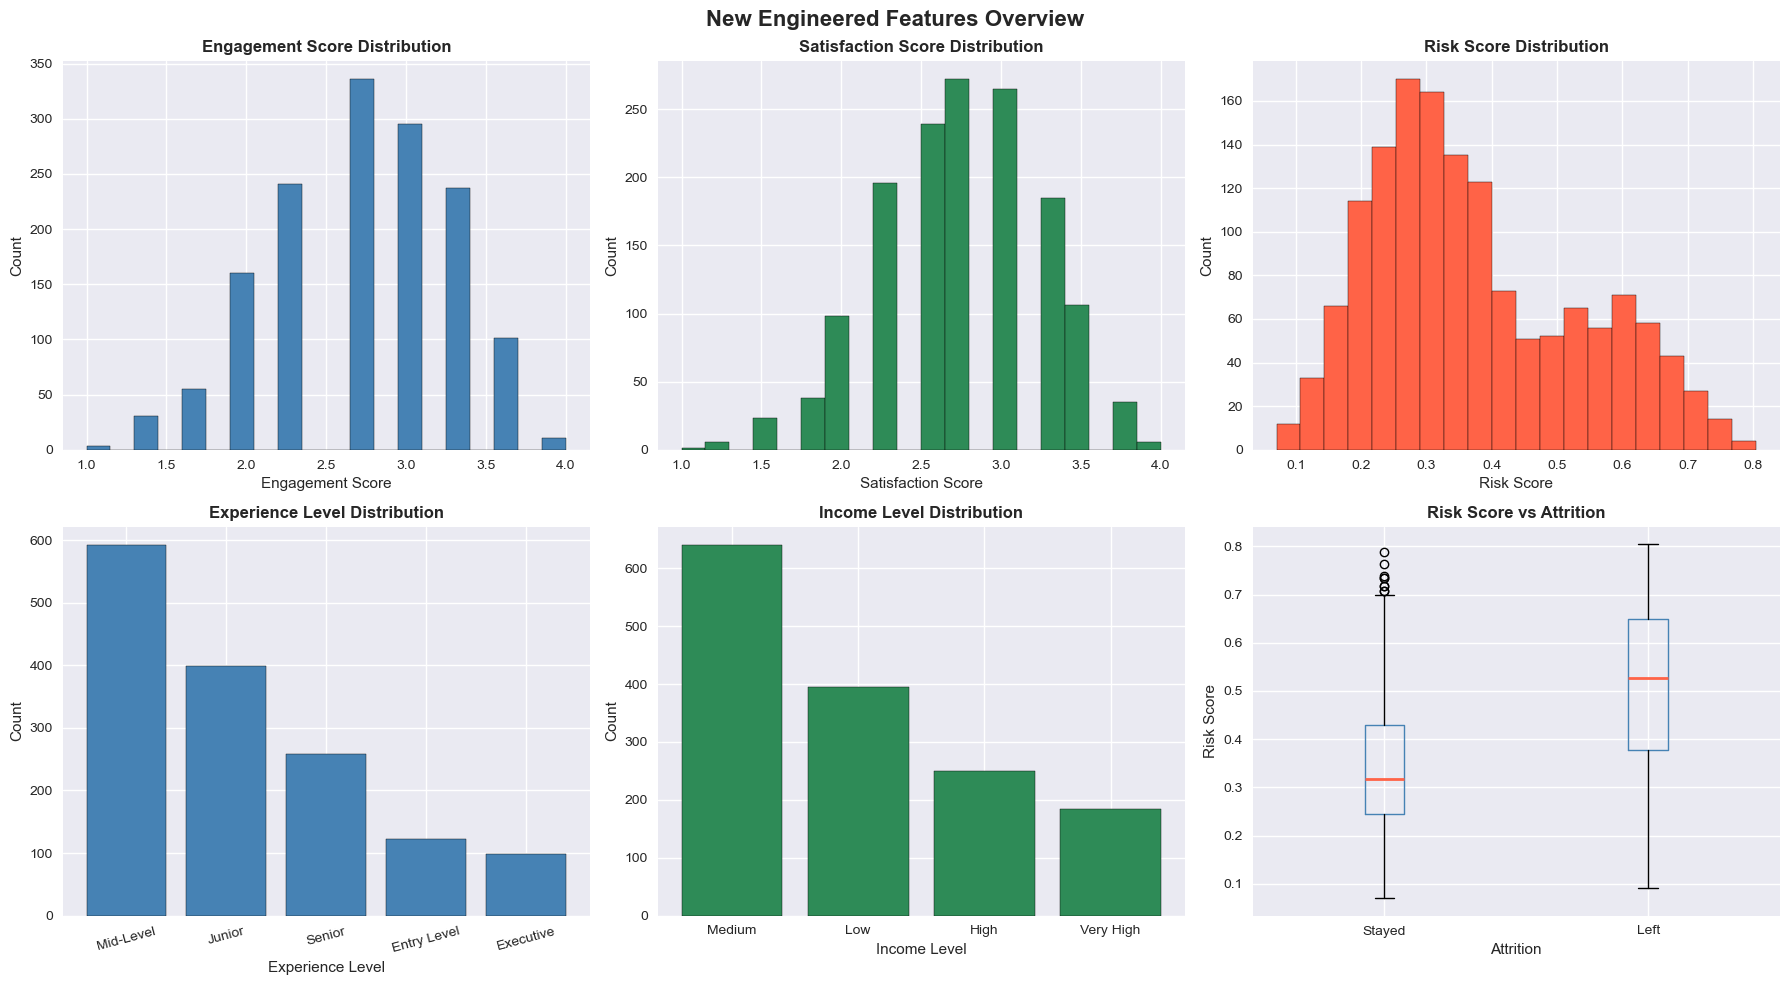

In [8]:
features_pdf = df.select(
    "EngagementScore", "SatisfactionScore", "RiskScore",
    "ExperienceLevel", "IncomeLevel", "Attrition_encoded"
).toPandas()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Engagement Score Distribution
axes[0, 0].hist(features_pdf["EngagementScore"], bins=20,
                color="steelblue", edgecolor="black")
axes[0, 0].set_title("Engagement Score Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Engagement Score")
axes[0, 0].set_ylabel("Count")

# 2. Satisfaction Score Distribution
axes[0, 1].hist(features_pdf["SatisfactionScore"], bins=20,
                color="seagreen", edgecolor="black")
axes[0, 1].set_title("Satisfaction Score Distribution", fontweight="bold")
axes[0, 1].set_xlabel("Satisfaction Score")
axes[0, 1].set_ylabel("Count")

# 3. Risk Score Distribution
axes[0, 2].hist(features_pdf["RiskScore"], bins=20,
                color="tomato", edgecolor="black")
axes[0, 2].set_title("Risk Score Distribution", fontweight="bold")
axes[0, 2].set_xlabel("Risk Score")
axes[0, 2].set_ylabel("Count")

# 4. Experience Level Distribution
exp_counts = features_pdf["ExperienceLevel"].value_counts()
axes[1, 0].bar(exp_counts.index, exp_counts.values,
               color="steelblue", edgecolor="black")
axes[1, 0].set_title("Experience Level Distribution", fontweight="bold")
axes[1, 0].set_xlabel("Experience Level")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis='x', rotation=15)

# 5. Income Level Distribution
inc_counts = features_pdf["IncomeLevel"].value_counts()
axes[1, 1].bar(inc_counts.index, inc_counts.values,
               color="seagreen", edgecolor="black")
axes[1, 1].set_title("Income Level Distribution", fontweight="bold")
axes[1, 1].set_xlabel("Income Level")
axes[1, 1].set_ylabel("Count")

# 6. Risk Score vs Attrition
axes[1, 2].boxplot(
    [features_pdf[features_pdf["Attrition_encoded"] == 0]["RiskScore"],
     features_pdf[features_pdf["Attrition_encoded"] == 1]["RiskScore"]],
    labels=["Stayed", "Left"],
    boxprops=dict(color="steelblue"),
    medianprops=dict(color="tomato", linewidth=2)
)
axes[1, 2].set_title("Risk Score vs Attrition", fontweight="bold")
axes[1, 2].set_xlabel("Attrition")
axes[1, 2].set_ylabel("Risk Score")

plt.suptitle("New Engineered Features Overview", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\feature_engineering.png", dpi=150)
plt.show()

### Feature Visualization Insights

The visualizations confirm that the engineered features are meaningful and well-distributed:

- **Engagement Score:** Normally distributed around 2.7, with most employees
  showing moderate engagement levels
- **Satisfaction Score:** Slightly right-skewed, with most employees scoring
  between 2.5 and 3.0, indicating moderate satisfaction
- **Risk Score:** The distribution shows a clear separation between employees
  who stayed and those who left. Employees who left have a significantly higher
  median risk score of approximately 0.52 compared to 0.33 for those who stayed,
  validating the effectiveness of our Risk Score formula
- **Experience Level:** Mid-Level employees form the largest group,
  followed by Junior employees
- **Income Level:** The majority of employees fall in the Medium and Low income categories

### 8. Save Engineered Dataset

We save the final dataset with all newly created features as a Parquet file
to be used in the model building phase.

In [9]:
from pyspark.ml.feature import StringIndexer

indexers = [
    StringIndexer(inputCol="ExperienceLevel", outputCol="ExperienceLevel_encoded", handleInvalid="keep"),
    StringIndexer(inputCol="IncomeLevel", outputCol="IncomeLevel_encoded", handleInvalid="keep")
]

from pyspark.ml import Pipeline
pipeline = Pipeline(stages=indexers)
df = pipeline.fit(df).transform(df)
df = df.drop("ExperienceLevel", "IncomeLevel")

df.write.mode("overwrite").parquet(
    r"C:\HR-Analytics-AI-System\data\hr_data_engineered.parquet"
)

print("Engineered dataset saved successfully.")
print(f"Location: C:\\HR-Analytics-AI-System\\data\\hr_data_engineered.parquet")
print(f"Total Rows: {df.count()}")
print(f"Total Columns: {len(df.columns)}")
print("-" * 40)
print("New Features Added:")
print("1. EngagementScore")
print("2. ExperienceLevel_encoded")
print("3. IncomeLevel_encoded")
print("4. SatisfactionScore")
print("5. RiskScore")

Engineered dataset saved successfully.
Location: C:\HR-Analytics-AI-System\data\hr_data_engineered.parquet
Total Rows: 1470
Total Columns: 36
----------------------------------------
New Features Added:
1. EngagementScore
2. ExperienceLevel_encoded
3. IncomeLevel_encoded
4. SatisfactionScore
5. RiskScore


### 9. Summary

In this notebook, we successfully completed the Feature Engineering phase.
The following new features were created and added to the dataset:

1. **EngagementScore:** Combines JobInvolvement, JobSatisfaction, and RelationshipSatisfaction into a single engagement indicator (average score: 2.72)
2. **ExperienceLevel:** Categorizes employees into Entry Level, Junior, Mid-Level, Senior, and Executive based on total working years
3. **IncomeLevel:** Categorizes employees into Low, Medium, High, and Very High based on monthly income
4. **SatisfactionScore:** Combines EnvironmentSatisfaction, JobSatisfaction, RelationshipSatisfaction, and WorkLifeBalance (average score: 2.73)
5. **RiskScore:** Estimates attrition likelihood based on overtime, engagement, satisfaction, tenure, and income (range: 0.07 to 0.80)

The final engineered dataset contains 1,470 rows and 36 columns,
and is ready for the next phase: Model Development.